# Cross-dataset pathway coverage comparison

💡 **Environment:** `clamp-analyses`

Compares MSigDB pathway coverage across three full CLAMP models:
- **ARCHS4**: `output/01_model_building/04_archs4/06_bp_coverage_rsmsigdb/06_bp_coverage_msigdb_rs_100/CLAMPfull_msigdb.rds`
- **GTEx** (all samples): `output/01_model_building/02_gtex/10_CLAMP_hall/CLAMPfull_hall.rds`
- **recount2** (all samples): `data/recount2/CLAMPfull_hall.rds`

In [1]:
library(here)
library(ggplot2)
library(dplyr)

source(here("config.R"))

theme_ng <- function() {
  theme_classic(base_size = 18) +
    theme(
      axis.title = element_text(size = 24, colour = "black"),
      axis.title.y = element_text(margin = margin(r = 18)),
      axis.text = element_text(size = 18, colour = "black"),
      axis.line = element_line(linewidth = 0.8, colour = "black"),
      axis.ticks = element_line(linewidth = 0.8, colour = "black"),
      axis.ticks.length = unit(0.22, "cm"),
      panel.grid.major.y = element_line(colour = "#BDBDBD", linewidth = 0.7),
      panel.grid.minor = element_blank(),
      legend.position = "right",
      legend.title = element_text(size = 18),
      legend.text = element_text(size = 16),
      plot.title = element_blank(),
      strip.background = element_blank(),
      strip.text = element_text(face = "bold", size = 18),
      plot.margin = margin(t = 16, r = 12, b = 12, l = 42)
    )
}

here() starts at /home/msubirana/Documents/pivlab/clamp-analyses




Attaching package: ‘dplyr’




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




## Define GetCLAMPPathwayCoverage

In [2]:
GetCLAMPPathwayCoverage <- function(clamp.results, fdr.cutoff = 0.05, auc.cutoff = 0.6) {
  summary.df     <- clamp.results$summary
  input.pathways <- colnames(clamp.results$C)
  num.lvs        <- ncol(clamp.results$U)

  sig.df       <- summary.df[summary.df$FDR < fdr.cutoff & summary.df$AUC > auc.cutoff, ]
  sig.pathways <- unique(sig.df$pathway)
  sig.lvs      <- unique(sig.df$LV)

  list(
    pathway           = length(sig.pathways) / length(input.pathways),
    lv                = length(sig.lvs) / num.lvs,
    sig.pathway.by.lv = length(sig.pathways) / num.lvs,
    n_sig_pathways    = length(sig.pathways),
    n_sig_lvs         = length(sig.lvs)
  )
}

## Load models and compute coverage

In [3]:
model_list <- list(
  list(
    dataset = "ARCHS4",
    # seed_1 only, per project convention (see hall_coverage_rs100_seed_1)
    path    = here("output/01_model_building/04_archs4/06_bp_coverage_rshall/06_bp_coverage_hall_rs_100/hall_coverage_rs100_seed_1/CLAMPfull_hall.rds")
  ),
  list(
    dataset = "GTEx",
    path    = here("output/01_model_building/02_gtex/10_CLAMP_hall/CLAMPfull_hall.rds")
  ),
  list(
    dataset = "recount2",
    path    = here("output/01_model_building/03_recount2/01_recount2_hall/CLAMPfull_hall.rds")
  )
)

FDR_CUTOFF <- 0.1
AUC_CUTOFF <- 0.6

results <- lapply(model_list, function(spec) {
  if (!file.exists(spec$path)) {
    warning("File not found: ", spec$path)
    return(NULL)
  }
  model    <- readRDS(spec$path)
  coverage <- GetCLAMPPathwayCoverage(model, fdr.cutoff = FDR_CUTOFF, auc.cutoff = AUC_CUTOFF)

  data.frame(
    dataset            = spec$dataset,
    n_samples          = ncol(model$B),
    n_input_pathways   = length(colnames(model$C)),
    n_lvs              = ncol(model$U),
    n_sig_pathways     = coverage$n_sig_pathways,
    n_sig_lvs          = coverage$n_sig_lvs,
    prop_pathway       = coverage$pathway,
    prop_lv            = coverage$lv,
    sig_pathway_per_lv = coverage$sig.pathway.by.lv,
    stringsAsFactors   = FALSE
  )
})

results_df <- do.call(rbind, Filter(Negate(is.null), results))
results_df$dataset <- factor(results_df$dataset, levels = c("GTEx", "recount2", "ARCHS4"))
rownames(results_df) <- NULL

message(sprintf("FDR < %.2f, AUC > %.1f", FDR_CUTOFF, AUC_CUTOFF))
print(results_df)

FDR < 0.10, AUC > 0.6



   dataset n_samples n_input_pathways n_lvs n_sig_pathways n_sig_lvs
1   ARCHS4    605614             2953  1728           1103       895
2     GTEx     17382             2990   578            688       344
3 recount2     37032             2427   724            813       494
  prop_pathway   prop_lv sig_pathway_per_lv
1    0.3735185 0.5179398          0.6383102
2    0.2301003 0.5951557          1.1903114
3    0.3349815 0.6823204          1.1229282


## Plots

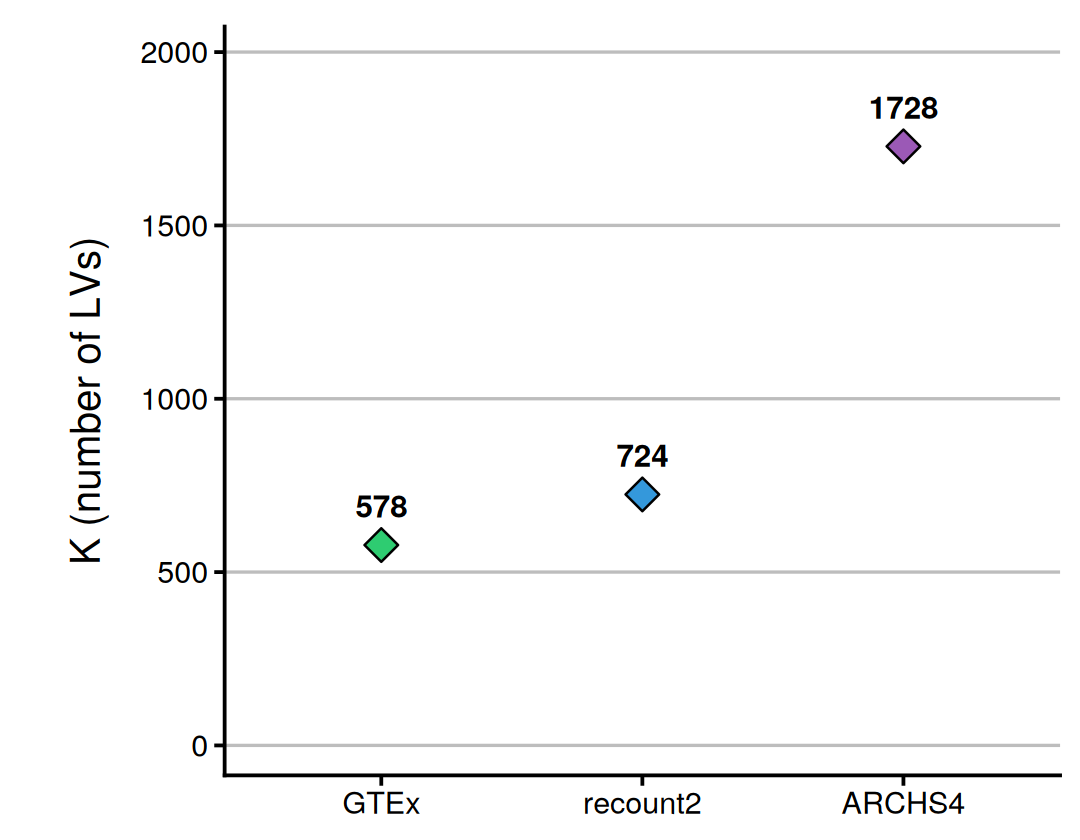

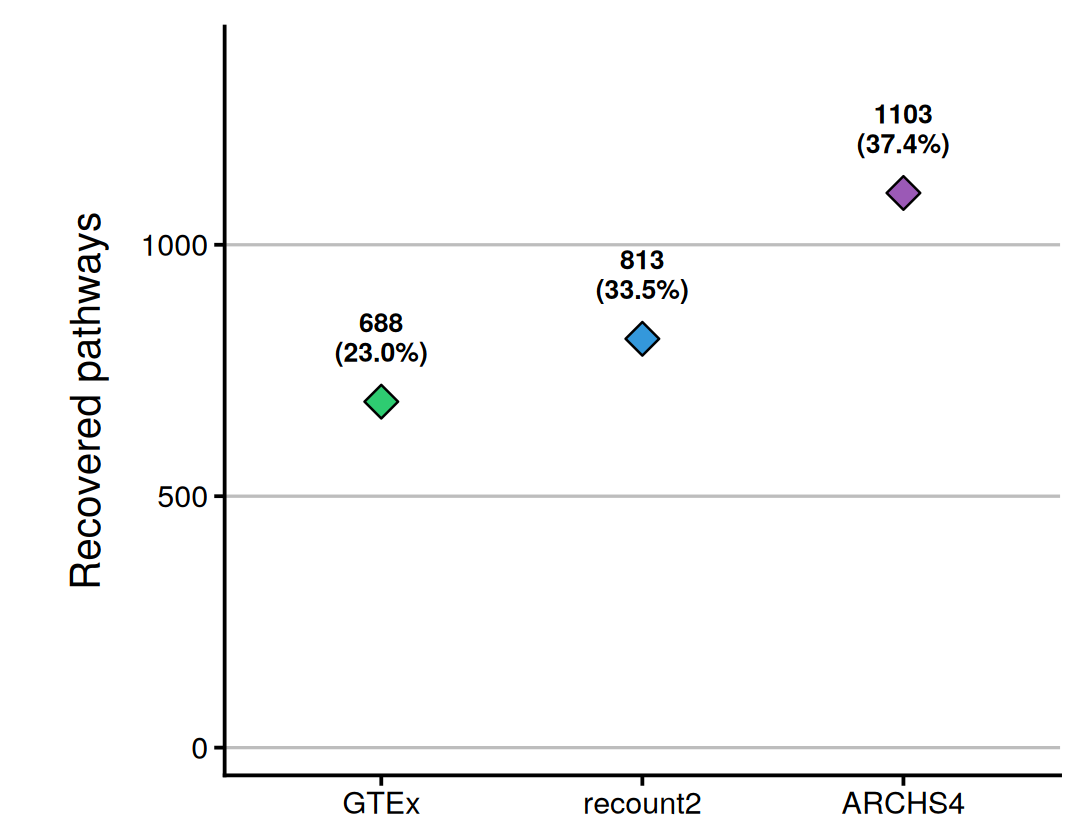

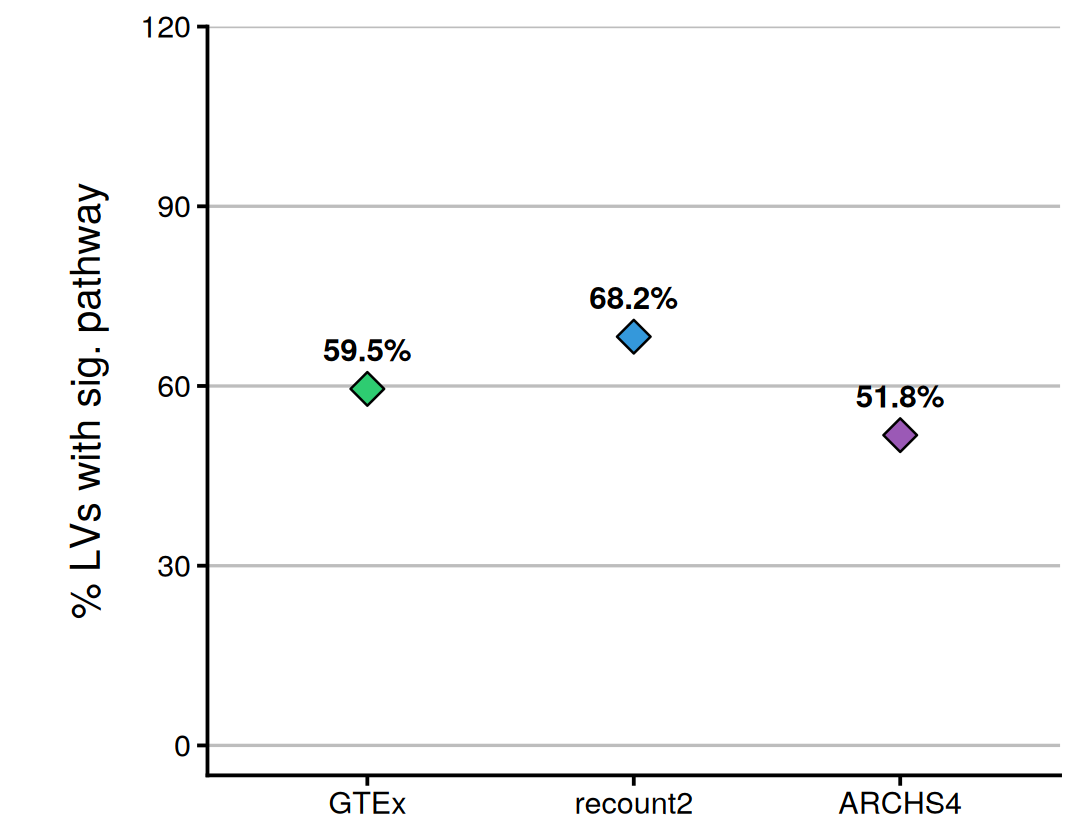

In [4]:
options(repr.plot.width = 9, repr.plot.height = 7)

dataset_colors <- c(
  ARCHS4   = "#9b59b6",
  recount2 = "#3498db",
  GTEx     = "#2ecc71"
)

p_lvs <- ggplot(results_df, aes(x = dataset, y = n_lvs, fill = dataset)) +
  geom_point(shape = 23, size = 7, colour = "black", stroke = 0.8) +
  geom_text(aes(label = n_lvs), vjust = -1.2, size = 6.5, fontface = "bold") +
  scale_fill_manual(values = dataset_colors, guide = "none") +
  scale_y_continuous(limits = c(0, NA), expand = expansion(mult = c(0.05, 0.20))) +
  labs(x = NULL, y = "K (number of LVs)") +
  theme_ng() +
  theme(legend.position = "none")

p_npaths <- ggplot(results_df, aes(x = dataset, y = n_sig_pathways, fill = dataset)) +
  geom_point(shape = 23, size = 7, colour = "black", stroke = 0.8) +
  geom_text(
    aes(label = paste0(n_sig_pathways, "\n(", sprintf("%.1f%%", prop_pathway * 100), ")")),
    vjust = -0.8, size = 5.5, fontface = "bold", lineheight = 0.95
  ) +
  scale_fill_manual(values = dataset_colors, guide = "none") +
  scale_y_continuous(limits = c(0, NA), expand = expansion(mult = c(0.05, 0.30))) +
  labs(x = NULL, y = "Recovered pathways") +
  theme_ng() +
  theme(legend.position = "none")

p_prop_lv <- ggplot(results_df, aes(x = dataset, y = prop_lv * 100, fill = dataset)) +
  geom_point(shape = 23, size = 7, colour = "black", stroke = 0.8) +
  geom_text(aes(label = sprintf("%.1f%%", prop_lv * 100)), vjust = -1.2, size = 6.5, fontface = "bold") +
  scale_fill_manual(values = dataset_colors, guide = "none") +
  scale_y_continuous(limits = c(0, 100), expand = expansion(mult = c(0.05, 0.20))) +
  labs(x = NULL, y = "% LVs with sig. pathway") +
  theme_ng() +
  theme(legend.position = "none")

p_lvs
p_npaths
p_prop_lv

In [5]:
options(repr.plot.width = 13, repr.plot.height = 7)

# Combined summary table as a plot
summary_long <- results_df %>%
  mutate(
    n_samples_fmt = format(n_samples, big.mark = ","),
    prop_pathway_fmt = sprintf("%.1f%%", prop_pathway * 100),
    prop_lv_fmt      = sprintf("%.1f%%", prop_lv * 100)
  ) %>%
  select(dataset, n_samples_fmt, n_lvs, n_input_pathways, n_sig_pathways, prop_pathway_fmt, prop_lv_fmt)

colnames(summary_long) <- c("Dataset", "Samples", "K (LVs)", "Input pathways", "Sig. pathways", "% pathways", "% LVs")

print(summary_long, row.names = FALSE)

  Dataset Samples K (LVs) Input pathways Sig. pathways % pathways % LVs
   ARCHS4 605,614    1728           2953          1103      37.4% 51.8%
     GTEx  17,382     578           2990           688      23.0% 59.5%
 recount2  37,032     724           2427           813      33.5% 68.2%


## Export for Figure 4

In [6]:
PANEL_DIR_FIG4 <- here('output/99_panels/fig4')
dir.create(PANEL_DIR_FIG4, recursive = TRUE, showWarnings = FALSE)
write.csv(results_df, file.path(PANEL_DIR_FIG4, 'model_pathway_coverage_seed1.csv'), row.names = FALSE)
message("Saved model_pathway_coverage_seed1.csv to ", PANEL_DIR_FIG4)

Saved model_pathway_coverage_seed1.csv to /home/msubirana/Documents/pivlab/clamp-analyses/output/99_panels/fig4

